In [9]:
import pandas as pd
import re

df = pd.read_csv('/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/datasets/wordanalysismediacloud.csv')

# Keywords to match — add or remove terms as needed
keywords = [
    r'\brape\b',
    r'\braped\b',
    r'\braping\b',
    r'\brapist\b',
    r'\bassault',
    r'\babuse',
    r'\bharassment',
    r'\bmisconduct',
    r'\bmetoo\b',
    r'#metoo',
    r'\bme too\b',
    r'\bsexual.violence',
    r'\bgroping\b',
    r'\bnonconsensual\b',
]

pattern = '|'.join(keywords)

# Search in title (case-insensitive)
mask = df['title'].str.contains(pattern, flags=re.IGNORECASE, na=False)

# Optionally also check the URL for additional signal
mask |= df['url'].str.contains(pattern, flags=re.IGNORECASE, na=False)

filtered = df[mask].copy()

print(f"Found {len(filtered)} matching rows out of {len(df)} total")
filtered.to_csv('/Users/liasymer/Desktop/QSS20/GitHub/FinalProj/LiaSFinalProject/datasets/filtered_metoo_assault.csv', index=False)

Found 26066 matching rows out of 93555 total


In [3]:
filtered["title"].head(10)

1     I’m Tired of Enduring the Abuse and Pain That ...
2     Hollywood sex scandal: See growing list of who...
5     How Will Netflix’s Sex-Fueled Mötley Crüe Movi...
34    "Me Too" creator Tarana Burke: "We have to mak...
40    Why is the New York Times defending sexual ass...
41    Azealia Banks Recounts Abuse by Coldplay Manag...
42    #MeToo: How an 11-year-old movement became a s...
43    Geraldo Rivera apologizes to Bette Midler afte...
44    Geraldo Rivera apologizes to Bette Midler afte...
45    Geraldo Rivera apologizes to Bette Midler afte...
Name: title, dtype: object

In [5]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize

import spacy
nlp = spacy.load('en_core_web_sm')

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

df = pd.read_csv('filtered_metoo_assault.csv')
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')
df['title_clean'] = df['title'].fillna('').str.strip()

metoo_movement            1.248945
survivor_focus            0.132970
perpetrator_focus         0.087202
institutional_response    0.054631
dtype: float64


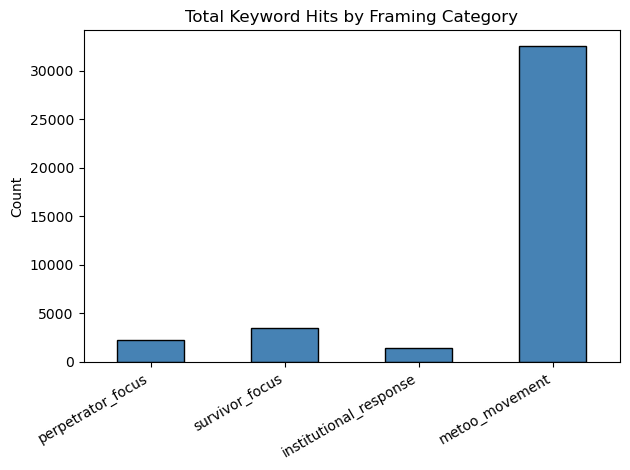

In [6]:
# Define thematic dictionaries
dictionaries = {
    'perpetrator_focus': [
        'accused', 'alleged', 'charged', 'convicted', 'arrested',
        'suspect', 'predator', 'abuser', 'offender'
    ],
    'survivor_focus': [
        'survivor', 'victim', 'spoke out', 'came forward', 'alleged victim',
        'accuser', 'complainant', 'testimony', 'rape'
    ],
    'institutional_response': [
        'fired', 'resigned', 'suspended', 'investigation', 'lawsuit',
        'settlement', 'trial', 'verdict', 'sentence', 'acquitted'
    ],
    'metoo_movement': [
        'metoo', 'me too', '#metoo', 'movement', 'reckoning',
        'misconduct', 'harassment', 'assault'
    ]
}

def score_title(title, word_list):
    title_lower = title.lower()
    return sum(1 for term in word_list if term in title_lower)

for category, words in dictionaries.items():
    df[category] = df['title_clean'].apply(lambda t: score_title(t, words))

# Summary: mean score per category
print(df[list(dictionaries.keys())].mean().sort_values(ascending=False))

# Bar chart of total hits per category
df[list(dictionaries.keys())].sum().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Keyword Hits by Framing Category')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

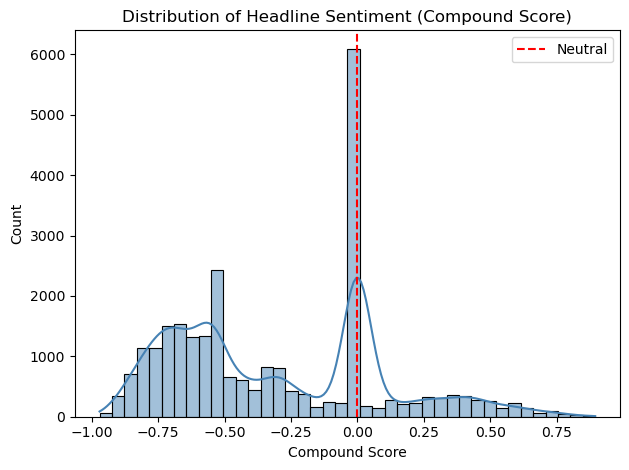

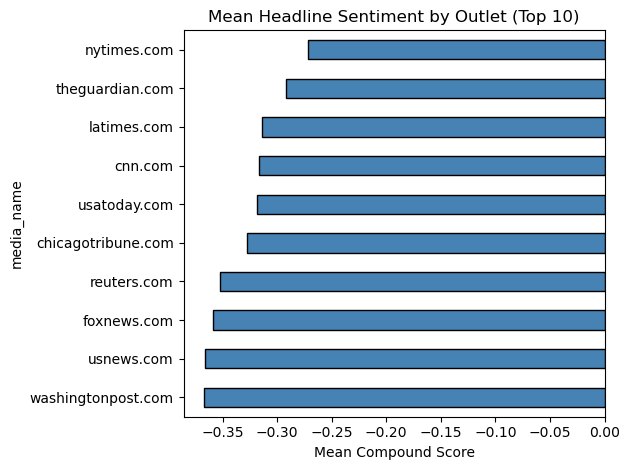

In [7]:
sia = SentimentIntensityAnalyzer()

# Extend lexicon with domain-relevant terms
domain_lexicon = {
    'survivor': 1.0,    # slightly positive framing
    'brave': 2.0,
    'courageous': 2.0,
    'alleged': -1.0,    # casts doubt
    'acquitted': 0.3,
    'strong': 1.0,
    'believe': 0.5,
    'reckoning': 1.0,
    'rallying': 1.5,
    'silence breaker': 2.0,
    'silence breakers': 2.0,
    'wins': 1.0,
    'victory': 1.5,
    'empower': 2
}
sia.lexicon.update(domain_lexicon)

df['sentiment'] = df['title_clean'].apply(sia.polarity_scores)
df['compound']  = df['sentiment'].apply(lambda x: x['compound'])
df['positive']  = df['sentiment'].apply(lambda x: x['pos'])
df['negative']  = df['sentiment'].apply(lambda x: x['neg'])
df['neutral']   = df['sentiment'].apply(lambda x: x['neu'])

# Distribution of compound scores
sns.histplot(df['compound'], bins=40, kde=True, color='steelblue')
plt.axvline(0, color='red', linestyle='--', label='Neutral')
plt.title('Distribution of Headline Sentiment (Compound Score)')
plt.xlabel('Compound Score')
plt.legend()
plt.tight_layout()
plt.show()

# Sentiment by media outlet (top 10 outlets by volume)
top_outlets = df['media_name'].value_counts().head(10).index
outlet_sentiment = (df[df['media_name'].isin(top_outlets)]
                    .groupby('media_name')['compound']
                    .mean()
                    .sort_values())

outlet_sentiment.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Mean Headline Sentiment by Outlet (Top 10)')
plt.xlabel('Mean Compound Score')
plt.tight_layout()
plt.show()

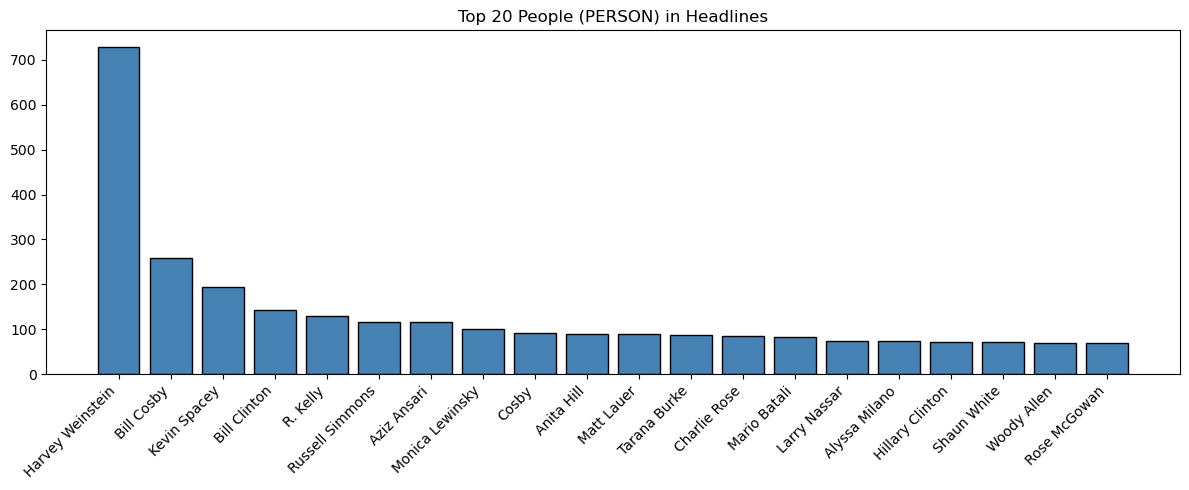

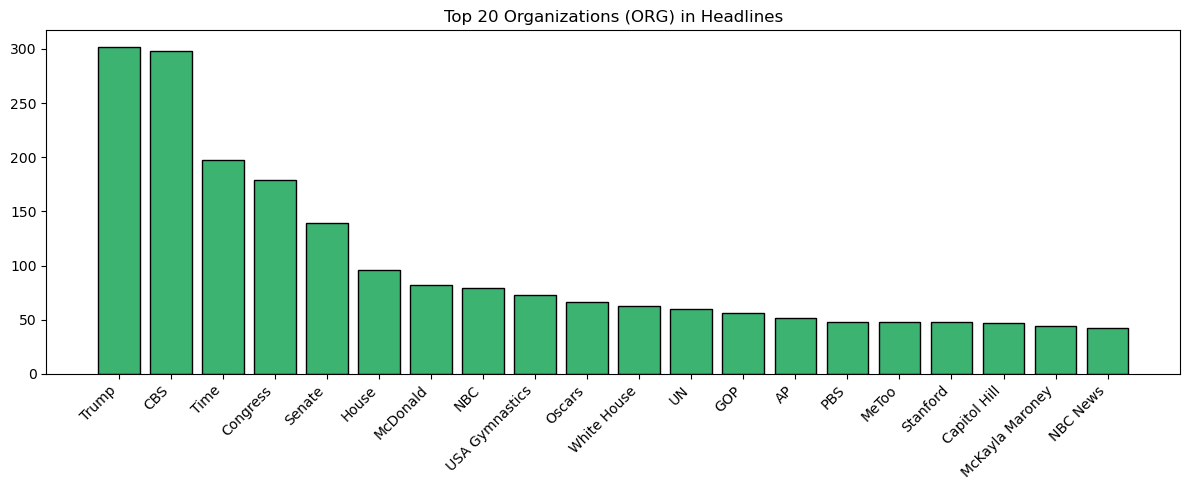

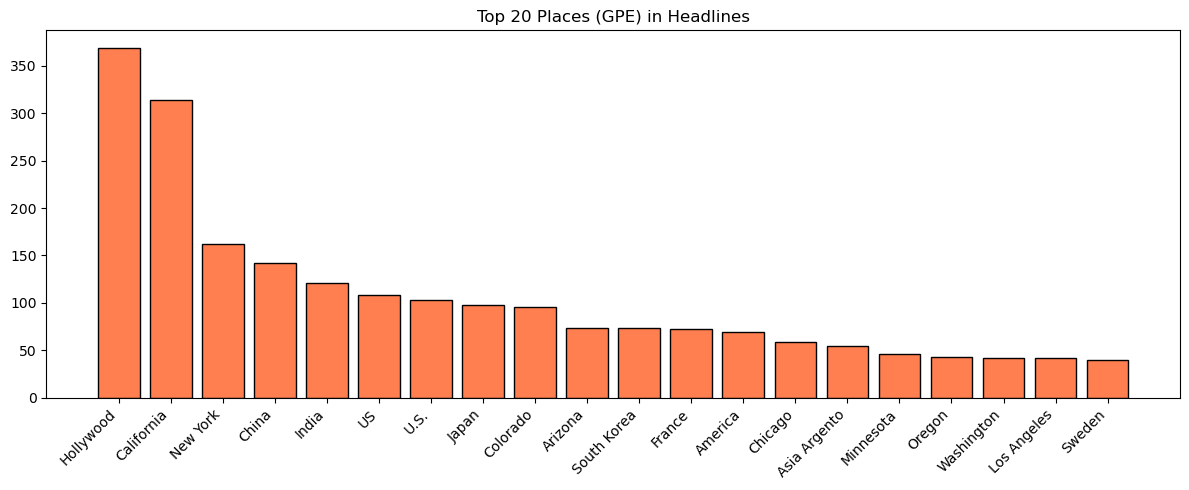

In [8]:
# Define blocklist for false positives
PERSON_BLOCKLIST = {
    'metoo', 'me too', 'me-too', '#metoo', 'metoo era', 'metoo movement',
    'meToo movement', 'meToo era', 'trump'  # add more as needed
}

# Normalize variations of the same name
NAME_NORMALIZATION = {
    'weinstein': 'Harvey Weinstein',
    'harvey weinstein': 'Harvey Weinstein',
    'metoo': None,  # will be filtered
    'me too': None,
    'meToo': None,
    'metoo era': None,
    'metoo movement': None,
}

def normalize_name(name):
    """Normalize name variations to canonical form."""
    lower = name.lower().strip()
    
    # Check blocklist first
    if lower in PERSON_BLOCKLIST:
        return None
    
    # Check normalization map
    if lower in NAME_NORMALIZATION:
        return NAME_NORMALIZATION[lower]
    
    return name.strip()

def get_entities(title, label):
    doc = nlp(title)
    entities = []
    for ent in doc.ents:
        if ent.label_ == label:
            if label == 'PERSON':
                normalized = normalize_name(ent.text)
                if normalized:
                    entities.append(normalized)
            else:
                entities.append(ent.text.strip())
    return entities

# Re-extract with cleaning
df['people'] = df['title_clean'].apply(lambda t: get_entities(t, 'PERSON'))
df['orgs']   = df['title_clean'].apply(lambda t: get_entities(t, 'ORG'))
df['places'] = df['title_clean'].apply(lambda t: get_entities(t, 'GPE'))

def plot_top_entities(col, label, color, n=20):
    all_ents = [e for sublist in df[col] for e in sublist]
    
    # Case-insensitive deduplication: keep the most common casing
    canonical = {}
    for e in all_ents:
        key = e.lower()
        canonical[key] = canonical.get(key, []) + [e]
    
    # Pick most frequent casing for each unique entity
    deduped = []
    for key, variants in canonical.items():
        best = Counter(variants).most_common(1)[0][0]
        deduped.extend([best] * len(variants))
    
    top = Counter(deduped).most_common(n)
    if not top:
        print(f"No entities found for {label}")
        return
    
    names, counts = zip(*top)
    plt.figure(figsize=(12, 5))
    plt.bar(names, counts, color=color, edgecolor='black')
    plt.title(f'Top {n} {label} in Headlines')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_top_entities('people', 'People (PERSON)', 'steelblue')
plot_top_entities('orgs',   'Organizations (ORG)', 'mediumseagreen')
plot_top_entities('places', 'Places (GPE)', 'coral')

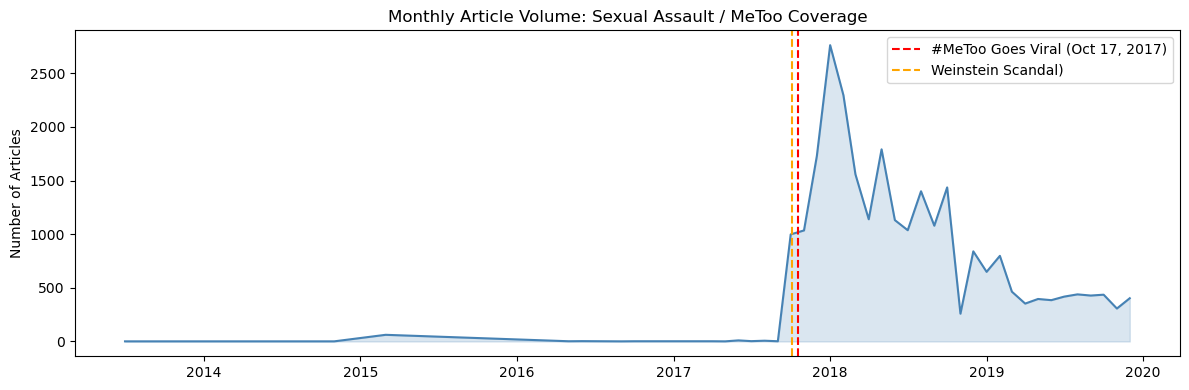

In [52]:
df_dated = df.dropna(subset=['publish_date']).copy()
df_dated['year_month'] = df_dated['publish_date'].dt.to_period('M')

# Article volume over time
volume = df_dated.groupby('year_month').size()
volume.index = volume.index.to_timestamp()

plt.figure(figsize=(12, 4))
plt.plot(volume.index, volume.values, color='steelblue')
plt.fill_between(volume.index, volume.values, alpha=0.2, color='steelblue')
plt.title('Monthly Article Volume: Sexual Assault / MeToo Coverage')
plt.axvline(x=pd.Timestamp('2017-10-17'), color='red', linestyle='--', 
            linewidth=1.5, label='#MeToo Goes Viral (Oct 17, 2017)')
plt.axvline(x=pd.Timestamp('2017-10-05'), color='orange', linestyle='--', 
            linewidth=1.5, label='Weinstein Scandal)')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.legend()
plt.show()


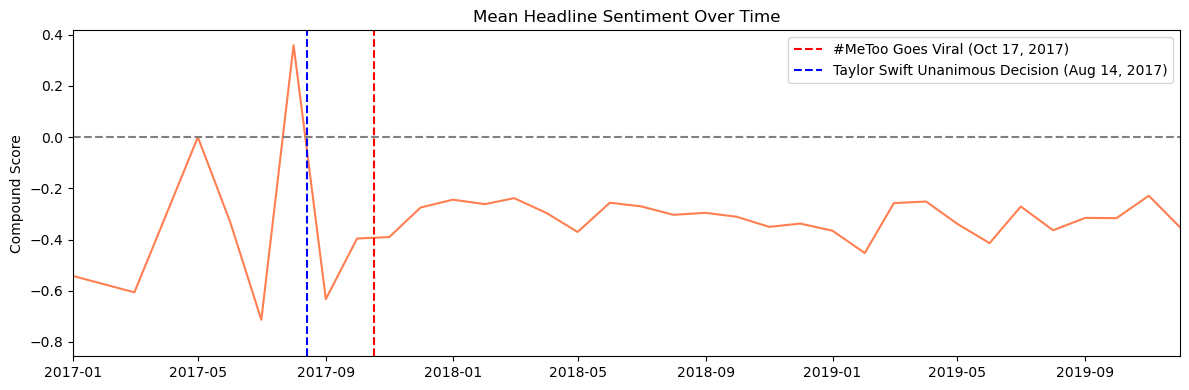

In [58]:
sent_time = df_dated.groupby('year_month')['compound'].mean()
sent_time.index = sent_time.index.to_timestamp()

plt.figure(figsize=(12, 4))
plt.plot(sent_time.index, sent_time.values, color='coral')
plt.axhline(0, color='gray', linestyle='--')

# Just pass the date directly since x-axis is datetime
plt.axvline(x=pd.Timestamp('2017-10-17'), color='red', linestyle='--', 
            linewidth=1.5, label='#MeToo Goes Viral (Oct 17, 2017)')
plt.axvline(x=pd.Timestamp('2017-08-14'), color='blue', linestyle='--', 
            linewidth=1.5, label='Taylor Swift Unanimous Decision (Aug 14, 2017)')
plt.title('Mean Headline Sentiment Over Time')
plt.ylabel('Compound Score')
plt.legend()
plt.xlim(pd.Timestamp('2017-01-01'), sent_time.index.max())
plt.tight_layout()
plt.show()